<a href="https://colab.research.google.com/github/Devi-Sunita/Codealpha_task/blob/main/task_1_web_scraping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

In [ ]:
url="https://books.toscrape.com/"
response= requests.get(url)
print(response.status_code)

200


In [ ]:
html=response.text
print(html[:1000])

<!DOCTYPE html>
<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!--> <html lang="en-us" class="no-js"> <!--<![endif]-->
    <head>
        <title>
    All products | Books to Scrape - Sandbox
</title>

        <meta http-equiv="content-type" content="text/html; charset=UTF-8" />
        <meta name="created" content="24th Jun 2016 09:29" />
        <meta name="description" content="" />
        <meta name="viewport" content="width=device-width" />
        <meta name="robots" content="NOARCHIVE,NOCACHE" />

        <!-- Le HTML5 shim, for IE6-8 support of HTML elements -->
        <!--[if lt IE 9]>
        <script src="//html5shim.googlecode.com/svn/trunk/html5.js"></script>
        <![endif]-->

        
            <link rel="shortcut icon" href="static/oscar/favicon.

In [ ]:
soup=BeautifulSoup(html,"html.parser")
print(soup.title.text)


    All products | Books to Scrape - Sandbox



In [ ]:
import requests
response=requests.get("https://books.toscrape.com/")
print(response.status_code)
print(len(response.text))


200
51294


In [ ]:
import requests
from bs4 import BeautifulSoup
url = "https://books.toscrape.com/"
response=requests.get(url)
html_content=response.text
soup=BeautifulSoup(html_content,"html.parser")
books=soup.find_all("article",
                    class_="product_pod")
print("number of books found:",len(books))

number of books found: 20


In [ ]:
book=books[0]
title=book.h3.a["title"]
print(title)

A Light in the Attic


In [ ]:
price=book.find("p",
                class_="price_color").text
print(price)

Â£51.77


In [ ]:
import requests
from bs4 import BeautifulSoup
url = "https://books.toscrape.com/"
response=requests.get(url)
soup=BeautifulSoup(response.text,'html.parser')
book=soup.find('article',class_='product_pod')
if book is not None:
  rating_element = book.find("p",class_="star-rating")
  if rating_element is not None:
     rating=rating_element["class"][1]
     print(rating)
  else:
    print("could not find")
else:
  print("could not find any article")

Three


In [ ]:
availability = book.find(
    "p",class_ = "instock availability"
).get_text(strip=True)
print(availability)


In stock


In [ ]:
book_link=book.h3.a["href"]
print(book_link)

catalogue/a-light-in-the-attic_1000/index.html


In [ ]:
books=soup.find_all("article",class_="product_pod")
books_data=[]
for book in books:
  title=book.h3.a["title"]
  price=book.find("p",
                class_="price_color").text.strip()
  rating=book.find(
      "p",class_="star-rating"
  )["class"][1]
  availability=book.find(
      "p",class_="instock availability"
  ).get_text(strip=True)
  book_link=book.h3.a["href"]
  books_data.append({
      "Title":title,
      "Price":price,
      "Rating":rating,
      "Availibility":availability,
      "Book_URL":book_link,
  })



In [ ]:
print(len(books_data))

20


In [ ]:
books_data=soup.find_all("article",class_="product_pod")
parsed_books=[]
for book in books_data:
  a_tag= book.select_one("h3 a")
  title=a_tag["title"] if a_tag and a_tag.has_attr("title") else "No Title"
  price_tag = book.select_one("p.price_color")
  price = price_tag.text if price_tag else "No Price"
  parsed_books.append({"Title":title,"Price":price})
import pandas as pd
df =pd.DataFrame(parsed_books)
df.head()

,Title,Price
0,A Light in the Attic,Â£51.77
1,Tipping the Velvet,Â£53.74
2,Soumission,Â£50.10
3,Sharp Objects,Â£47.82
4,Sapiens: A Brief History of Humankind,Â£54.23


In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
all_books=[]
base_url="https://books.toscrape.com/catalogue/page-{}.html"
for page in range(1,51):
  url=base_url.format(page)
  response = requests.get(url)
  soup=BeautifulSoup(response.text,"html.parser")
  books=soup.find_all(
      "article",class_="product_pod"
  )
  for book in books:
    title=book.h3.a["title"]
    price=book.find("p",class_="price_color").text.strip()
    rating=book.find("p",class_="star-rating")["class"][1]
    availability=book.find("p",class_="instock availability").get_text(strip=True)
    book_link=book.h3.a["href"]
    all_books.append({
        "Title":title,
        "Price":price,
        "rating":rating,
        "Availability":availability,
        "Book_URL":book_link
    })
    print(f"Page{page} completed")
    time.sleep(1)
    print("Total books:",len(all_books))

Page1 completed
Total books: 1
Page1 completed
Total books: 2
Page1 completed
Total books: 3
Page1 completed
Total books: 4
Page1 completed
Total books: 5
Page1 completed
Total books: 6
Page1 completed
Total books: 7
Page1 completed
Total books: 8
Page1 completed
Total books: 9
Page1 completed
Total books: 10
Page1 completed
Total books: 11
Page1 completed
Total books: 12
Page1 completed
Total books: 13
Page1 completed
Total books: 14
Page1 completed
Total books: 15
Page1 completed
Total books: 16
Page1 completed
Total books: 17
Page1 completed
Total books: 18
Page1 completed
Total books: 19
Page1 completed
Total books: 20
Page2 completed
Total books: 21
Page2 completed
Total books: 22
Page2 completed
Total books: 23
Page2 completed
Total books: 24
Page2 completed
Total books: 25
Page2 completed
Total books: 26
Page2 completed
Total books: 27
Page2 completed
Total books: 28
Page2 completed
Total books: 29
Page2 completed
Total books: 30
Page2 completed
Total books: 31
Page2 completed
T

In [ ]:
df=pd.DataFrame(all_books)
df.head(10)
df.shape

(1000, 5)

200
<!DOCTYPE html>
<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!--> <html lang="en-us" class="no-js"> <!--<![endif]-->
    <head>
        <title>
    All products | Books to Scrape - Sandbox
</title>

        <meta http-equiv="content-type" content="text/html; charset=UTF-8" />
        <meta name="created" content="24th Jun 2016 09:29" />
        <meta name="description" content="" />
        <meta name="viewport" content="width=device-width" />
        <meta name="robots" content="NOARCHIVE,NOCACHE" />

        <!-- Le HTML5 shim, for IE6-8 support of HTML elements -->
        <!--[if lt IE 9]>
        <script src="//html5shim.googlecode.com/svn/trunk/html5.js"></script>
        <![endif]-->

        
            <link rel="shortcut icon" href="static/oscar/favi

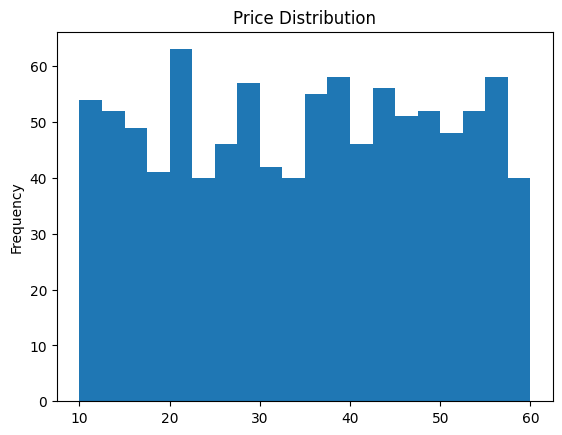

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
url="https://books.toscrape.com/"
response=requests.get(url)
print(response.status_code)
html=response.text
print(html[:1000])
all_books=[]
base_url="https://books.toscrape.com/catalogue/page-{}.html"
for page in range(1,51):
  page_url=base_url.format(page)
  response=requests.get(page_url)
  soup=BeautifulSoup(response.text,"html.parser")
  books_data=soup.find_all("article",class_="product_pod")

  for book in books_data:
      a_tag=book.select_one("h3 a")
      title = a_tag["title"] if a_tag and a_tag.has_attr("title") else "No Title"
      price_tag=book.select_one("p.price_color")
      price=price_tag.text if price_tag else "No Price"

      rating_tag=book.select_one("p.star-rating")
      rating=rating_tag["class"][1] if rating_tag and len(rating_tag["class"])>1 else "No Rating"

      availability_tag=book.select_one("p.instock.availability")
      availability = availability_tag.text.strip() if availability_tag else "No Availability"

      book_url= a_tag["href"] if a_tag else "No URL"
      all_books.append({
        "Title":title,
        "Price":price,
        "rating":rating,
        "Availability":availability,
        "Book_URL":book_url
    })
print(f"Total books:{len(all_books)}")
print(f"Page {page} completed")
time.sleep(0.5)
df=pd.DataFrame(all_books)
df.head(10)
df.shape

import pandas as pd
import matplotlib.pyplot as plt

print(df.columns)
target_col="Price"
df[target_col ]=df[target_col].astype(str).str.replace(r"[^\d.]","",regex=True)
df[target_col]=df[target_col].str.replace(",","",regex=False).str.strip()
df[target_col]=pd.to_numeric(df[target_col],errors="coerce")

df[target_col].plot(kind="hist",bins=20,title=("Price Distribution"))
df.head()
df.to_csv("books_scraped_dataset.csv",index=False)
print("Dataset saved successfully")

In [ ]:
print(df.columns)

Index(['Title', 'Price', 'rating', 'Availability', 'Book_URL', 'target_col'], dtype='object')


In [ ]:
df.columns=df.columns.str.strip()
rating_map={
    "One":1,
    "Two":2,
    "Three":3,
    "Four":4,
    "Five":5
}
df["rating"]=df["rating"].map(rating_map)

In [ ]:
print(df.info())
print(df.isnull().sum())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         1000 non-null   object 
 1   Price         1000 non-null   float64
 2   rating        1000 non-null   object 
 3   Availability  1000 non-null   object 
 4   Book_URL      1000 non-null   object 
dtypes: float64(1), object(4)
memory usage: 39.2+ KB
None
Title           0
Price           0
rating          0
Availability    0
Book_URL        0
dtype: int64
(1000, 5)


In [ ]:
df.to_csv("books_scraped_dataset.csv",
          index=False)
print("Dataset saved successfully!")

Dataset saved successfully!
